# 20.7 題目和答案都在輸入裡，模型究竟練哪一段？


訓練紙寫「桌上有幾隻貓？」和「兩隻」。題目提供線索，回答才是要練的輸出。對話SFT因此讓問題、圖片及歷史仍可讀，只把指定助理答案與結束位置計入代價；不是把題目從視野遮掉。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

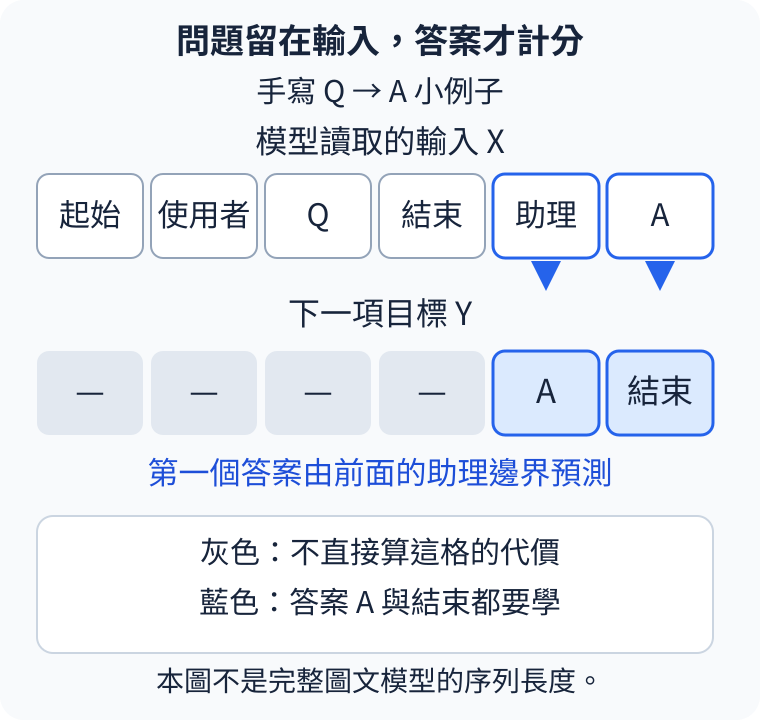

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/natural-v4-answer-mask.svg")))

圖中在「助理」這格預測 A 時，只能讀到這格為止的前文，右邊的 A 尚不可讀；到了 A 這格，才以它作前文來預測結束。這是[7.4](https://birdhackor.github.io/tiny-perceptron-vlm/7.4.html)的下一位置對齊，避免把待猜答案提前交給預測位置。


In [3]:
from tiny_perceptron.data import render_chat

x, y = render_chat(
    [
        {"role": "user", "content": "Q"},
        {"role": "assistant", "content": "A"},
    ]
)
active = y != -100
first = active.nonzero()[0].item()
print("輸入位置數", len(x))
print("計分目標數", active.sum().item())
print("第一個計分目標的位置", first)
print("計分目標ID", y[active].tolist())

輸入位置數 6
計分目標數 2
第一個計分目標的位置 4
計分目標ID [73, 2]


局部byte範例把Q、A各編成一格，共六格輸入。有效目標是A與結束，共兩格，第一格在0起算的位置4。`-100`是忽略計分的目標標記，不是輸入字表編號。它讓我們看下一位置對齊，沒有假定完整Qwen圖片輸入也只有六格。

真正資料用底座處理器轉圖片，並用配套模板整理角色。完成編碼後才計長度；截掉答案尾端或結束，會改變原示範要教的工作。逐筆核對有效目標與保留範圍，比單純問「句子夠不夠短」準確。

練習把小例A改成AB，預測有效目標由2增至3，問題仍在前文，再核對計分位置。
